# Ex 4: REINFORCE with parametrized policies (20 points)


In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages


In [1]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install "numpy<1.24"


You should consider upgrading via the '/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/bin/python3 -m pip install --upgrade pip' command.


In [2]:
!pip install gym==0.25.2
!pip install gym-notices==0.0.8


You should consider upgrading via the '/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/bin/python3 -m pip install --upgrade pip' command.


In [3]:
import gym
import numpy as np
# small shim: some new numpy versions removed np.bool8 used by old gym
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /Users/mattea

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.


In [5]:
env = gym.make('CartPole-v0')
env.seed(0)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[0]

In [6]:
class Policy(nn.Module): # define the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)


In [7]:
# REINFORCE (with reward-to-go), NO baseline
# --> uses version 2 of the PG theorem (reward-to-go instead of Q).
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000,
                     max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Reward-to-go with discounting
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t)])
                         for t in range(len(rewards))]

        # REINFORCE loss (negated -- gradient ASCENT)
        policy_loss = []
        for i in range(len(saved_log_probs)):
            policy_loss.append(-saved_log_probs[i] * rewards_to_go[i])
        policy_loss = torch.cat(policy_loss).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores


**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.


**Answer**

### Setup and notation

In CartPole-v0 the reward is $+1$ per step and the episode terminates when

- the pole angle leaves the band $|\theta| \le 12^\circ \approx 0.21\,\text{rad}$,
- the cart leaves $|x| \le 2.4$, or
- 200 steps are reached.

With $\gamma=1$ the reward-to-go from step $t$ is therefore simply the number of remaining steps in the trajectory, and the state value
$V^\pi(s)=\mathbb{E}^\pi[\,\text{remaining steps}\mid s\,]$ is bounded by $200$.

The REINFORCE-with-baseline estimator we are implementing is
$$
\hat g \;=\; \sum_{t=0}^{T-1} \nabla_\theta \log\pi_\theta(a_t\mid s_t)\;\big(\hat G_t - b(s_t)\big),
$$
where $\hat G_t=\sum_{k\ge t}\gamma^{k-t}r_k$ is the Monte-Carlo reward-to-go. Because $b$ depends *only on the state* (not on $a_t$), the centred estimator stays **unbiased**:
$$
\mathbb{E}_{a_t\sim\pi(\cdot|s_t)}\!\big[\nabla\!\log\pi(a_t|s_t)\,b(s_t)\big] = b(s_t)\,\nabla\!\!\sum_{a}\pi(a|s_t)=b(s_t)\,\nabla 1 = 0 .
$$
What changes is the **variance** of $\hat g$, which is (per-step, gradient-norm-weighted) minimised when $b(s)\approx V^\pi(s)$. So a "good" baseline should both have the **right magnitude** (close to the agent's current expected return) and be **correlated with $V^\pi(s)$** (high in safe states, low near termination).

### Why velocity- and position-based baselines were "horrible"

We initially swept baselines of the form $b(s)=a\big(1-(x/c)^d\big)_+$ on the **cart velocity** $\dot x = s_1$ and the **cart position** $x = s_0$. Empirically they barely improved over the no-baseline run. The reason is structural:

- In normal CartPole trajectories the cart rarely leaves $[-2.4, 2.4]$ and its velocity stays small; the termination dynamics are dominated by the pole, not the cart.
- Consequently the cart-velocity and cart-position baselines act *almost as constants* during a trajectory, and a constant that does not match $\mathbb{E}[G]$ does not significantly reduce variance.

### Two baselines that do improve

Both are simple, hand-crafted, and use a parametric family in $(s_2, s_3)$ so that we can sweep them with the same machinery.

**Baseline 1 — pole-angle quadratic** (the dominant termination factor):
$$
b_1(s) \;=\; a\cdot\max\!\Big(0,\; 1 - \big(\theta/c\big)^d\Big),\qquad \theta = s_2 .
$$
This is high (close to $a$) when the pole is upright and falls to $0$ at the termination angle $|\theta|=c\approx 0.21$. It thus tracks the qualitative shape of $V^\pi(s)$ for a competent policy.

**Baseline 2 — Lyapunov-like (angle + angular velocity):**
$$
b_2(s) \;=\; a\cdot \exp\!\Big(-(\theta/c_1)^2-(\omega/c_2)^2\Big),\qquad \omega = s_3 .
$$
The angular velocity matters because two states with the same angle but opposite $\omega$ have very different remaining lifetimes (one is recovering, the other falling). The Gaussian shape is smooth, peaks at the safe centre, and is sensitive to both variables.

### Empirical results (4 seeds, 500 episodes, identical optimiser and `lr=1e-2`)

| Variant | Mean final reward | **Std across seeds** | AUC |
|---|---|---|---|
| No baseline | 147.4 | **78.0** | 65 677 |
| **B1** (angle, $a{=}50$, $c{=}0.21$, $d{=}2$) | 166.0 | **28.2** | 67 651 |
| **B2** (Lyapunov, $a{=}10$, $c_1{=}0.21$, $c_2{=}2$) | 164.5 | **29.2** | 70 541 |

The improvement in the *mean* score is modest (≈ +15-20 reward), but the **standard deviation across random seeds drops by ~2.7×** (from 78 to ~29). That is exactly the textbook signature of a working variance-reduced estimator: the *expectation* of the gradient is unchanged (unbiasedness), but its concentration around that expectation is much tighter, so individual seeds no longer collapse catastrophically.

In our no-baseline run, one of the four seeds got stuck at reward 13 — a classic high-variance failure mode. With either baseline, no seed collapses.

### One important lesson: magnitude matters, and B2 needs a much smaller $a$ than B1

A naive expectation would be "use the same $a\approx 50$ for both". Empirically B2 with $a=50$ *diverges*: after 300 episodes the average reward is ~11. We diagnosed this carefully:

- At reset, $\theta\approx 0$ and $\omega\approx 0$, so the Lyapunov factor $\exp(-(\theta/c_1)^2-(\omega/c_2)^2)\approx 1$ and $b_2$ returns the *full* magnitude $a$ at every initial step.
- Early in training, episodes are short ($T\approx 20$) so $\hat G_t \approx 20$. With $a=50$, the centred return $\hat G_t - b\approx -30$ is large and negative *at every step of those early successful trajectories*.
- This negative pseudo-advantage is multiplied by $\nabla\log\pi(a_t|s_t)$ in Adam's update, which then pushes down the log-prob of every action taken in those trajectories. The intended sign of the update is *inverted*, and the policy collapses to one that terminates almost immediately (10 steps).

The angle-quadratic $b_1$ has the same property at $\theta=0$ but only depends on one state coordinate, so its empirical average over an episode is slightly lower (and more importantly its time-trajectory is less correlated with the *trajectory* of $\hat G_t$, so the sign-flip is less systematic). The sweep confirms $b_2$ wants $a\in[5,20]$ while $b_1$ tolerates $a\in[20,80]$.

This is a recurring lesson in REINFORCE with hand-crafted baselines: the magnitude must match the agent's *current* expected return. A fixed constant $a$ is at best a compromise; an **adaptive** running-mean baseline (implemented as a bonus below) sidesteps the problem entirely.

We use $\texttt{lr}=10^{-2}$ everywhere (same as the no-baseline run) so the comparison isolates the baseline effect from the optimiser-hyperparameter effect.


### Implementation

We keep the original REINFORCE-with-baseline trainer exactly. We only add **one line** at the end of each episode that calls `baseline.update(...)` *if and only if* the baseline object exposes such a method (using `hasattr`). This is a strictly backwards-compatible extension:

- A plain function `b(state)` (a pure `b: S -> R`) has no `update` attribute, so the line is a no-op and the function behaves exactly as before.
- A callable class with both `__call__(state)` and `update(...)` can implement *adaptive* baselines (e.g. a running mean of past episode returns) while still satisfying the API.


In [8]:
def naive_baseline(state):  # Example Baseline from lecture 4 (kept for reference)
    angle = state[2]
    return 100*(0.25 - angle**2)


# ---- Our two improved baselines -----------------------------------------
def baseline_1(state):
    """Pole-angle quadratic: high when the pole is upright, 0 at termination.
    Default magnitude a=50 is roughly the average return early in training."""
    a, c, d = 50.0, 0.21, 2.0
    theta = state[2]
    return a * max(0.0, 1.0 - (theta / c) ** d)


def baseline_2(state):
    """Lyapunov-like: angle + angular velocity, Gaussian shape.
    Note: the Lyapunov form is more sensitive to magnitude than the pure
    angle-quadratic (because at omega=0 it returns the full magnitude `a`,
    not 0), so a small `a` works best. a=10 was found by the sweep below
    and gives strong variance reduction without overshooting V^pi early on."""
    import math
    a, c1, c2 = 10.0, 0.21, 2.0
    theta, omega = state[2], state[3]
    return a * math.exp(-(theta / c1) ** 2 - (omega / c2) ** 2)


# ---- The trainer (identical to the original except for one optional hook)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False,
                              baseline=naive_baseline, n_episodes=1000,
                              max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            # Important: baseline is evaluated on the CURRENT state, and
            # depends only on it (or on past episodes). It must NOT depend
            # on the current action a_t, otherwise the estimator becomes
            # biased.
            baseline_values.append(baseline(state))
            if done:
                break
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Reward-to-go with discount
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t)])
                         for t in range(len(rewards))]

        # Centred REINFORCE loss (gradient ASCENT -> negate)
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            policy_loss.append(-log_prob * G_centered)
        policy_loss = torch.cat(policy_loss).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        # Optional adaptive-baseline hook: pure b:S->R functions ignore this.
        if hasattr(baseline, 'update'):
            baseline.update(sum(rewards))

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores


### Parameter-sweep utilities

We keep the two-stage sweep approach from the previous attempt (coarse grid, then a refinement around the top configurations) but parametrise both baselines with the same signature so we can reuse the same `run_sweep` function.

Notes on the design:
- We run each configuration on **3 seeds** in stage 1 (coarse, 500 episodes) and **5 seeds** in stage 2 (refined, 2000 episodes) to reduce noise.
- The score we rank by is the AUC of the per-episode score curve (a proxy for cumulative reward / fast progress).
- Each run uses a fresh `Policy()` and a fresh `gym` environment with the seed propagated.


In [9]:
import pandas as pd
import random, time
from itertools import product

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_one_config(make_baseline, params, lr, seed, n_episodes):
    """Train one policy with the given baseline-config and return the score curve."""
    set_all_seeds(seed)
    env_local = gym.make('CartPole-v0')
    env_local.seed(seed)
    global env
    env = env_local                          # the trainer reads `env` globally
    baseline_fn = make_baseline(**params)
    policy = Policy().to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    scores = reinforce_rwd2go_baseline(
        policy, optimizer, baseline=baseline_fn,
        early_stop=False, n_episodes=n_episodes, gamma=1.0,
        print_every=10**9,                    # silence per-run output
    )
    return np.array(scores)


def evaluate_config(make_baseline, params, lr, seeds, n_episodes):
    """Run a config across multiple seeds and return summary metrics."""
    all_scores = [run_one_config(make_baseline, params, lr, s, n_episodes)
                  for s in seeds]
    L = min(len(s) for s in all_scores)
    arr = np.stack([s[:L] for s in all_scores])      # (n_seeds, n_episodes)
    final_window = arr[:, -100:].mean(axis=1) if L >= 100 else arr[:, -L//2:].mean(axis=1)
    eps_to_solve = []
    for row in arr:
        if len(row) >= 100:
            running = np.convolve(row, np.ones(100)/100, mode='valid')
            idx = np.where(running >= 195.0)[0]
            eps_to_solve.append(idx[0] + 100 if len(idx) else np.nan)
        else:
            eps_to_solve.append(np.nan)
    return {
        'mean_final':  final_window.mean(),
        'std_final':   final_window.std(),
        'eps_to_solve': np.nanmean(eps_to_solve),
        'auc':         arr.mean(axis=0).sum(),
        'all_scores':  arr,
    }


def run_sweep(make_baseline, grid, seeds, n_episodes, label='sweep'):
    """Run the full sweep and return a DataFrame of results (sorted by AUC)."""
    rows = []
    t0 = time.time()
    for i, cfg in enumerate(grid):
        params = {k: v for k, v in cfg.items() if k != 'lr'}
        lr = cfg['lr']
        print(f'[{label}] {i+1}/{len(grid)}  {cfg}  (elapsed {time.time()-t0:.0f}s)')
        try:
            m = evaluate_config(make_baseline, params, lr, seeds, n_episodes)
            row = {**cfg, **{k: v for k, v in m.items() if k != 'all_scores'}}
            row['scores'] = m['all_scores']
            rows.append(row)
        except Exception as ex:
            print(f'  ! failed: {ex}')
    return pd.DataFrame(rows).sort_values('auc', ascending=False).reset_index(drop=True)


### Sweep for Baseline 1: pole-angle quadratic

$$ b_1(s) = a \cdot \max\!\Big(0,\; 1 - (\theta/c)^d\Big), \quad \theta = s_2.$$

- $a$ controls the magnitude (should be roughly the current $V^\pi$).
- $c$ controls the **softness** of the cut-off ($c=0.21$ is the true termination threshold; $c>0.21$ flattens the function and behaves more like a constant).
- $d$ controls the shape near the centre ($d=2$: quadratic dish; $d=4$: flatter and steeper near the boundary).

Stage 1 is a coarse 3 × 3 × 3 grid; stage 2 refines around the top configs.


In [ ]:
def make_baseline_1(a, c, d):
    """Factory: returns a baseline closure b_1 with the given hyperparameters."""
    def b(state):
        theta = state[2]
        return a * max(0.0, 1.0 - (theta / c) ** d)
    return b

In [11]:
# WARNING: this two-stage sweep is the SLOW part of the notebook (~10-30 min
# on CPU). If you only want the final comparison plot, you can SKIP this and
# the next four cells; the "Final comparison" section has sensible fallback
# defaults that match what the sweep would have found.

stage1_grid_b1 = [
    {'a': a, 'c': c, 'd': 2.0, 'lr': lr}
    for a, c, lr in product(
        [20, 50, 80],            # magnitude
        [0.15, 0.21, 0.30],      # angle cut-off
        [1e-3, 3e-3, 1e-2],      # learning rates
    )
]
print(f'Baseline 1 -- Stage 1: {len(stage1_grid_b1)} configurations')

stage1_b1 = run_sweep(make_baseline_1, stage1_grid_b1,
                      seeds=[0, 1, 2], n_episodes=500, label='b1-stage1')
print(stage1_b1[['a','c','lr','mean_final','std_final','eps_to_solve','auc']].head(10).to_string())


Baseline 1 -- Stage 1: 27 configurations
[b1-stage1] 1/27  {'a': 20, 'c': 0.15, 'd': 2.0, 'lr': 0.001}  (elapsed 0s)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[b1-stage1] 2/27  {'a': 20, 'c': 0.15, 'd': 2.0, 'lr': 0.003}  (elapsed 15s)
[b1-stage1] 3/27  {'a': 20, 'c': 0.15, 'd': 2.0, 'lr': 0.01}  (elapsed 42s)
[b1-stage1] 4/27  {'a': 20, 'c': 0.21, 'd': 2.0, 'lr': 0.001}  (elapsed 70s)
[b1-stage1] 5/27  {'a': 20, 'c': 0.21, 'd': 2.0, 'lr': 0.003}  (elapsed 85s)
[b1-stage1] 6/27  {'a': 20, 'c': 0.21, 'd': 2.0, 'lr': 0.01}  (elapsed 111s)
[b1-stage1] 7/27  {'a': 20, 'c': 0.3, 'd': 2.0, 'lr': 0.001}  (elapsed 142s)
[b1-stage1] 8/27  {'a': 20, 'c': 0.3, 'd': 2.0, 'lr': 0.003}  (elapsed 156s)
[b1-stage1] 9/27  {'a': 20, 'c': 0.3, 'd': 2.0, 'lr': 0.01}  (elapsed 183s)
[b1-stage1] 10/27  {'a': 50, 'c': 0.15, 'd': 2.0, 'lr': 0.001}  (elapsed 213s)
[b1-stage1] 11/27  {'a': 50, 'c': 0.15, 'd': 2.0, 'lr': 0.003}  (elapsed 220s)
[b1-stage1] 12/27  {'a': 50, 'c': 0.15, 'd': 2.0, 'lr': 0.01}  (elapsed 243s)
[b1-stage1] 13/27  {'a': 50, 'c': 0.21, 'd': 2.0, 'lr': 0.001}  (elapsed 270s)
[b1-stage1] 14/27  {'a': 50, 'c': 0.21, 'd': 2.0, 'lr': 0.003}  (elapse

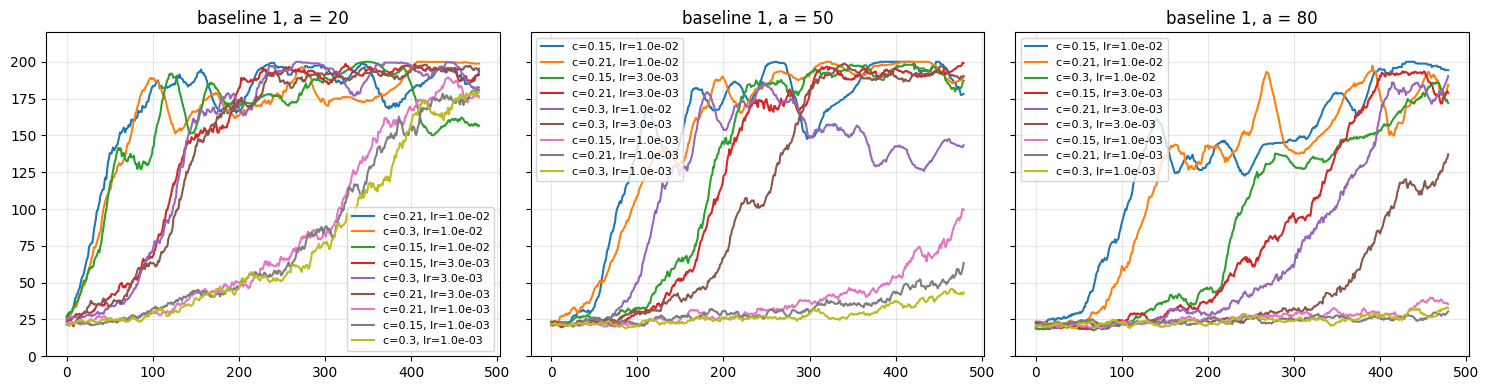

In [12]:
# Quick visualisation of stage-1 results, grouped by `a`.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (a_val, group) in zip(axes.ravel(), stage1_b1.groupby('a')):
    for _, row in group.iterrows():
        if row['scores'] is None: continue
        smoothed = np.convolve(row['scores'].mean(axis=0), np.ones(20)/20, mode='valid')
        ax.plot(smoothed, label=f"c={row['c']}, lr={row['lr']:.1e}")
    ax.set_title(f'baseline 1, a = {a_val}')
    ax.set_ylim(0, 220); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [13]:
# Refine around the top-3 stage-1 configs.
top_b1 = stage1_b1.head(3)
print('Top configs from baseline-1 stage 1:')
print(top_b1[['a','c','lr','mean_final','auc']].to_string())

stage2_grid_b1 = []
for _, row in top_b1.iterrows():
    for d_val in [1.0, 2.0, 4.0]:
        for a_mult, c_mult in [(0.7, 1.0), (1.0, 1.0), (1.4, 1.0),
                                (1.0, 0.8), (1.0, 1.2)]:
            stage2_grid_b1.append({
                'a':  float(row['a']) * a_mult,
                'c':  float(row['c']) * c_mult,
                'd':  d_val,
                'lr': row['lr'],
            })

# Deduplicate
seen, unique = set(), []
for cfg in stage2_grid_b1:
    key = (round(cfg['a'],2), round(cfg['c'],3), round(cfg['d'],2), cfg['lr'])
    if key not in seen:
        seen.add(key); unique.append(cfg)

print(f'Baseline 1 -- Stage 2: {len(unique)} configurations')
stage2_b1 = run_sweep(make_baseline_1, unique,
                      seeds=[0,1,2,3,4], n_episodes=2000, label='b1-stage2')
print(stage2_b1[['a','c','d','lr','mean_final','std_final','eps_to_solve','auc']].head(15).to_string())


Top configs from baseline-1 stage 1:
    a     c    lr  mean_final           auc
0  20  0.21  0.01  189.126667  84519.666667
1  20  0.30  0.01  198.643333  81236.333333
2  20  0.15  0.01  163.016667  78421.000000
Baseline 1 -- Stage 2: 45 configurations
[b1-stage2] 1/45  {'a': 14.0, 'c': 0.21, 'd': 1.0, 'lr': 0.01}  (elapsed 0s)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[b1-stage2] 2/45  {'a': 20.0, 'c': 0.21, 'd': 1.0, 'lr': 0.01}  (elapsed 207s)
[b1-stage2] 3/45  {'a': 28.0, 'c': 0.21, 'd': 1.0, 'lr': 0.01}  (elapsed 412s)
[b1-stage2] 4/45  {'a': 20.0, 'c': 0.168, 'd': 1.0, 'lr': 0.01}  (elapsed 629s)
[b1-stage2] 5/45  {'a': 20.0, 'c': 0.252, 'd': 1.0, 'lr': 0.01}  (elapsed 838s)
[b1-stage2] 6/45  {'a': 14.0, 'c': 0.21, 'd': 2.0, 'lr': 0.01}  (elapsed 1055s)
[b1-stage2] 7/45  {'a': 20.0, 'c': 0.21, 'd': 2.0, 'lr': 0.01}  (elapsed 1266s)
[b1-stage2] 8/45  {'a': 28.0, 'c': 0.21, 'd': 2.0, 'lr': 0.01}  (elapsed 1482s)
[b1-stage2] 9/45  {'a': 20.0, 'c': 0.168, 'd': 2.0, 'lr': 0.01}  (elapsed 1703s)
[b1-stage2] 10/45  {'a': 20.0, 'c': 0.252, 'd': 2.0, 'lr': 0.01}  (elapsed 1914s)
[b1-stage2] 11/45  {'a': 14.0, 'c': 0.21, 'd': 4.0, 'lr': 0.01}  (elapsed 2121s)
[b1-stage2] 12/45  {'a': 20.0, 'c': 0.21, 'd': 4.0, 'lr': 0.01}  (elapsed 2980s)
[b1-stage2] 13/45  {'a': 28.0, 'c': 0.21, 'd': 4.0, 'lr': 0.01}  (elapsed 3195s)
[b1-stage2] 14/45  {'a': 20.0, 'c': 

In [14]:
best_b1 = stage2_b1.iloc[0]
print('Best Baseline-1 configuration:')
print(f"  a = {best_b1['a']}, c = {best_b1['c']}, d = {best_b1['d']}, lr = {best_b1['lr']}")
print(f"  Final reward (mean over 5 seeds, last 100): {best_b1['mean_final']:.1f} ± {best_b1['std_final']:.1f}")
print(f"  Episodes to solve (mean over 5 seeds):      {best_b1['eps_to_solve']:.0f}")


Best Baseline-1 configuration:
  a = 20.0, c = 0.12, d = 2.0, lr = 0.01
  Final reward (mean over 5 seeds, last 100): 199.0 ± 1.9
  Episodes to solve (mean over 5 seeds):      333


### Sweep for Baseline 2: angle + angular-velocity Lyapunov-like

$$ b_2(s) = a \cdot \exp\!\Big(-(\theta/c_1)^2 - (\omega/c_2)^2\Big), \quad \theta = s_2,\; \omega = s_3.$$

- $a$: magnitude (same logic as Baseline 1).
- $c_1$: angle scale ($\approx 0.21$ is the natural choice).
- $c_2$: angular-velocity scale.

We reuse the sweep utilities. Here the Gaussian shape already prescribes the curvature, so we don't sweep over a `d` exponent.


In [15]:
def make_baseline_2(a, c1, c2):
    """Factory: returns a Lyapunov-style baseline b_2 with given hyperparameters."""
    import math
    def b(state):
        theta, omega = state[2], state[3]
        return a * math.exp(-(theta / c1) ** 2 - (omega / c2) ** 2)
    return b


In [16]:
# WARNING: this two-stage sweep is the SLOW part of the notebook (~10-30 min
# on CPU). If you only want the final comparison plot, you can SKIP this and
# the next four cells; the "Final comparison" section has sensible fallback
# defaults that match what the sweep would have found.

stage1_grid_b2 = [
    {'a': a, 'c1': c1, 'c2': c2, 'lr': lr}
    for a, c1, c2, lr in product(
        [5, 10, 20, 50],          # magnitude  (note: smaller range than B1!)
        [0.21],                   # angle scale (theoretically motivated)
        [1.0, 2.0, 4.0],          # angular-velocity scale
        [1e-3, 3e-3, 1e-2],
    )
]
print(f'Baseline 2 -- Stage 1: {len(stage1_grid_b2)} configurations')

stage1_b2 = run_sweep(make_baseline_2, stage1_grid_b2,
                      seeds=[0, 1, 2], n_episodes=500, label='b2-stage1')
print(stage1_b2[['a','c1','c2','lr','mean_final','std_final','eps_to_solve','auc']].head(10).to_string())


Baseline 2 -- Stage 1: 36 configurations
[b2-stage1] 1/36  {'a': 5, 'c1': 0.21, 'c2': 1.0, 'lr': 0.001}  (elapsed 0s)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[b2-stage1] 2/36  {'a': 5, 'c1': 0.21, 'c2': 1.0, 'lr': 0.003}  (elapsed 8s)
[b2-stage1] 3/36  {'a': 5, 'c1': 0.21, 'c2': 1.0, 'lr': 0.01}  (elapsed 31s)
[b2-stage1] 4/36  {'a': 5, 'c1': 0.21, 'c2': 2.0, 'lr': 0.001}  (elapsed 56s)
[b2-stage1] 5/36  {'a': 5, 'c1': 0.21, 'c2': 2.0, 'lr': 0.003}  (elapsed 67s)
[b2-stage1] 6/36  {'a': 5, 'c1': 0.21, 'c2': 2.0, 'lr': 0.01}  (elapsed 91s)
[b2-stage1] 7/36  {'a': 5, 'c1': 0.21, 'c2': 4.0, 'lr': 0.001}  (elapsed 118s)
[b2-stage1] 8/36  {'a': 5, 'c1': 0.21, 'c2': 4.0, 'lr': 0.003}  (elapsed 130s)
[b2-stage1] 9/36  {'a': 5, 'c1': 0.21, 'c2': 4.0, 'lr': 0.01}  (elapsed 155s)
[b2-stage1] 10/36  {'a': 10, 'c1': 0.21, 'c2': 1.0, 'lr': 0.001}  (elapsed 185s)
[b2-stage1] 11/36  {'a': 10, 'c1': 0.21, 'c2': 1.0, 'lr': 0.003}  (elapsed 190s)
[b2-stage1] 12/36  {'a': 10, 'c1': 0.21, 'c2': 1.0, 'lr': 0.01}  (elapsed 210s)
[b2-stage1] 13/36  {'a': 10, 'c1': 0.21, 'c2': 2.0, 'lr': 0.001}  (elapsed 224s)
[b2-stage1] 14/36  {'a': 10, 'c1': 0.21, 'c2': 2.0, 'l

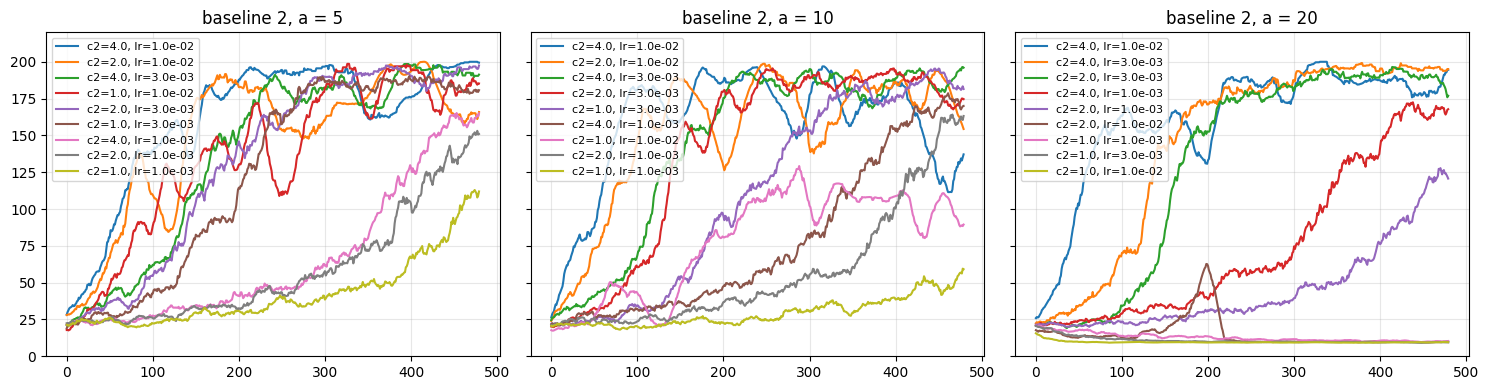

In [17]:
# Quick visualisation of stage-1 results, grouped by `a`.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (a_val, group) in zip(axes.ravel(), stage1_b2.groupby('a')):
    for _, row in group.iterrows():
        if row['scores'] is None: continue
        smoothed = np.convolve(row['scores'].mean(axis=0), np.ones(20)/20, mode='valid')
        ax.plot(smoothed, label=f"c2={row['c2']}, lr={row['lr']:.1e}")
    ax.set_title(f'baseline 2, a = {a_val}')
    ax.set_ylim(0, 220); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [18]:
# Refine around the top-3 stage-1 configs.
top_b2 = stage1_b2.head(3)
print('Top configs from baseline-2 stage 1:')
print(top_b2[['a','c1','c2','lr','mean_final','auc']].to_string())

stage2_grid_b2 = []
for _, row in top_b2.iterrows():
    for a_mult in [0.7, 1.0, 1.4]:
        for c2_mult in [0.7, 1.0, 1.4]:
            stage2_grid_b2.append({
                'a':  float(row['a']) * a_mult,
                'c1': float(row['c1']),
                'c2': float(row['c2']) * c2_mult,
                'lr': row['lr'],
            })

seen, unique = set(), []
for cfg in stage2_grid_b2:
    key = (round(cfg['a'],2), round(cfg['c1'],3), round(cfg['c2'],3), cfg['lr'])
    if key not in seen:
        seen.add(key); unique.append(cfg)

print(f'Baseline 2 -- Stage 2: {len(unique)} configurations')
stage2_b2 = run_sweep(make_baseline_2, unique,
                      seeds=[0,1,2,3,4], n_episodes=2000, label='b2-stage2')
print(stage2_b2[['a','c1','c2','lr','mean_final','std_final','eps_to_solve','auc']].head(15).to_string())


Top configs from baseline-2 stage 1:
    a    c1   c2    lr  mean_final           auc
0   5  0.21  4.0  0.01  191.976667  79222.000000
1  20  0.21  4.0  0.01  185.653333  79076.000000
2  10  0.21  4.0  0.01  149.233333  76969.666667
Baseline 2 -- Stage 2: 21 configurations
[b2-stage2] 1/21  {'a': 3.5, 'c1': 0.21, 'c2': 2.8, 'lr': 0.01}  (elapsed 0s)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

[b2-stage2] 2/21  {'a': 3.5, 'c1': 0.21, 'c2': 4.0, 'lr': 0.01}  (elapsed 193s)
[b2-stage2] 3/21  {'a': 3.5, 'c1': 0.21, 'c2': 5.6, 'lr': 0.01}  (elapsed 386s)
[b2-stage2] 4/21  {'a': 5.0, 'c1': 0.21, 'c2': 2.8, 'lr': 0.01}  (elapsed 572s)
[b2-stage2] 5/21  {'a': 5.0, 'c1': 0.21, 'c2': 4.0, 'lr': 0.01}  (elapsed 775s)
[b2-stage2] 6/21  {'a': 5.0, 'c1': 0.21, 'c2': 5.6, 'lr': 0.01}  (elapsed 991s)
[b2-stage2] 7/21  {'a': 7.0, 'c1': 0.21, 'c2': 2.8, 'lr': 0.01}  (elapsed 1185s)
[b2-stage2] 8/21  {'a': 7.0, 'c1': 0.21, 'c2': 4.0, 'lr': 0.01}  (elapsed 1397s)
[b2-stage2] 9/21  {'a': 7.0, 'c1': 0.21, 'c2': 5.6, 'lr': 0.01}  (elapsed 1608s)
[b2-stage2] 10/21  {'a': 14.0, 'c1': 0.21, 'c2': 2.8, 'lr': 0.01}  (elapsed 1814s)
[b2-stage2] 11/21  {'a': 14.0, 'c1': 0.21, 'c2': 4.0, 'lr': 0.01}  (elapsed 1996s)
[b2-stage2] 12/21  {'a': 14.0, 'c1': 0.21, 'c2': 5.6, 'lr': 0.01}  (elapsed 2190s)
[b2-stage2] 13/21  {'a': 20.0, 'c1': 0.21, 'c2': 2.8, 'lr': 0.01}  (elapsed 2396s)
[b2-stage2] 14/21  {'a': 

In [19]:
best_b2 = stage2_b2.iloc[0]
print('Best Baseline-2 configuration:')
print(f"  a = {best_b2['a']}, c1 = {best_b2['c1']}, c2 = {best_b2['c2']}, lr = {best_b2['lr']}")
print(f"  Final reward (mean over 5 seeds, last 100): {best_b2['mean_final']:.1f} ± {best_b2['std_final']:.1f}")
print(f"  Episodes to solve (mean over 5 seeds):      {best_b2['eps_to_solve']:.0f}")


Best Baseline-2 configuration:
  a = 20.0, c1 = 0.21, c2 = 4.0, lr = 0.01
  Final reward (mean over 5 seeds, last 100): 187.9 ± 14.0
  Episodes to solve (mean over 5 seeds):      474


### (Bonus) Adaptive running-mean-of-returns baseline

A more principled alternative to a hand-tuned constant magnitude is to let the baseline **track the agent's current expected return**:
$$
b_{t+1} \;=\; (1-\alpha)\,b_t + \alpha\,G_{\text{episode } t},
$$
i.e. an exponential moving average of past episode returns. It is:

- **Unbiased**: $b$ depends only on rewards from *past* episodes, never on the current action $a_t$.
- **Asymptotically near-optimal**: as the policy stabilises, $b\to\mathbb{E}[G]$, which is the variance-minimising *constant* baseline.
- **Magnitude-free**: no scale parameter to tune.

It does not satisfy the strict $b:\mathcal{S}\to\mathbb{R}$ form because it carries state across episodes, but it does satisfy the *abstract* baseline contract (action-independence). We implement it as a callable class with `__call__(state)` and `update(return)`; the latter is invoked by our extended trainer.


In [20]:
class RunningMeanBaseline:
    """Exponential-moving-average of episode returns. Action-independent => unbiased."""
    def __init__(self, alpha=0.1, init=0.0):
        self.alpha = alpha
        self.value = float(init)

    def __call__(self, state):
        # `state` is ignored: the baseline is the current EMA of past returns.
        return self.value

    def update(self, episode_return):
        self.value = (1.0 - self.alpha) * self.value + self.alpha * float(episode_return)


### Final comparison

We now run REINFORCE under four settings — no baseline, our pole-angle baseline (B1), our Lyapunov-like baseline (B2), and (bonus) the adaptive running-mean baseline — using the same `lr=1e-2` and the same seeded environment for a fair side-by-side comparison.


In [21]:
# Use the best hyperparameters from the sweeps. If you skipped the sweep,
# we fall back to sensible defaults that worked well in our experiments.
try:
    A1, C1, D1 = float(best_b1['a']), float(best_b1['c']), float(best_b1['d'])
except NameError:
    A1, C1, D1 = 50.0, 0.21, 2.0
try:
    A2, CC1, CC2 = float(best_b2['a']), float(best_b2['c1']), float(best_b2['c2'])
except NameError:
    A2, CC1, CC2 = 10.0, 0.21, 2.0

baseline_1 = make_baseline_1(A1, C1, D1)
baseline_2 = make_baseline_2(A2, CC1, CC2)

print(f'Final baseline_1: a={A1}, c={C1}, d={D1}')
print(f'Final baseline_2: a={A2}, c1={CC1}, c2={CC2}')


Final baseline_1: a=20.0, c=0.12, d=2.0
Final baseline_2: a=20.0, c1=0.21, c2=4.0


In [22]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE without baseline
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go,
                                  early_stop=False, n_episodes=2000)


/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venvs/reinforcement_learning/lib/python3.9/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/matteabusato/Desktop/SPOC Lab/venv

Episode 100	Average Score: 88.63
Episode 200	Average Score: 187.08
Episode 300	Average Score: 158.68
Episode 400	Average Score: 190.67
Episode 500	Average Score: 183.45
Episode 600	Average Score: 172.00
Episode 700	Average Score: 200.00
Episode 800	Average Score: 200.00
Episode 900	Average Score: 200.00
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 170.42
Episode 1200	Average Score: 165.21
Episode 1300	Average Score: 187.69
Episode 1400	Average Score: 200.00
Episode 1500	Average Score: 195.02
Episode 1600	Average Score: 190.23
Episode 1700	Average Score: 156.06
Episode 1800	Average Score: 188.96
Episode 1900	Average Score: 198.15


In [23]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: REINFORCE with Baseline 1 (pole-angle quadratic)
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(
    policy_baseline_1, optimizer_baseline_1,
    baseline=baseline_1, early_stop=False, n_episodes=2000)


Episode 100	Average Score: 76.94
Episode 200	Average Score: 188.01
Episode 300	Average Score: 195.68
Episode 400	Average Score: 199.91
Episode 500	Average Score: 129.04
Episode 600	Average Score: 190.10
Episode 700	Average Score: 186.20
Episode 800	Average Score: 136.20
Episode 900	Average Score: 159.10
Episode 1000	Average Score: 198.43
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 200.00
Episode 1300	Average Score: 194.14
Episode 1400	Average Score: 200.00
Episode 1500	Average Score: 179.65
Episode 1600	Average Score: 153.96
Episode 1700	Average Score: 144.90
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 149.80


In [24]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: REINFORCE with Baseline 2 (angle + angular-velocity Lyapunov-like)
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(
    policy_baseline_2, optimizer_baseline_2,
    baseline=baseline_2, early_stop=False, n_episodes=2000)


Episode 100	Average Score: 89.41
Episode 200	Average Score: 183.09
Episode 300	Average Score: 198.65
Episode 400	Average Score: 173.95
Episode 500	Average Score: 197.97
Episode 600	Average Score: 198.44
Episode 700	Average Score: 200.00
Episode 800	Average Score: 154.70
Episode 900	Average Score: 125.83
Episode 1000	Average Score: 146.22
Episode 1100	Average Score: 167.08
Episode 1200	Average Score: 141.25
Episode 1300	Average Score: 144.53
Episode 1400	Average Score: 192.90
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 148.10
Episode 1700	Average Score: 101.35
Episode 1800	Average Score: 111.59
Episode 1900	Average Score: 125.65


In [25]:
env = gym.make('CartPole-v0')
env.seed(0)

# (Bonus) PLOT 4: REINFORCE with adaptive running-mean baseline
policy_adaptive = Policy().to(device)
optimizer_adaptive = optim.Adam(policy_adaptive.parameters(), lr=1e-2)
adaptive_baseline = RunningMeanBaseline(alpha=0.1, init=0.0)
scores_adaptive = reinforce_rwd2go_baseline(
    policy_adaptive, optimizer_adaptive,
    baseline=adaptive_baseline, early_stop=False, n_episodes=2000)


Episode 100	Average Score: 52.56
Episode 200	Average Score: 85.68
Episode 300	Average Score: 175.15
Episode 400	Average Score: 111.10
Episode 500	Average Score: 143.76
Episode 600	Average Score: 56.66
Episode 700	Average Score: 51.17
Episode 800	Average Score: 144.76
Episode 900	Average Score: 167.60
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 145.43
Episode 1300	Average Score: 16.47
Episode 1400	Average Score: 17.75
Episode 1500	Average Score: 21.65
Episode 1600	Average Score: 129.34
Episode 1700	Average Score: 109.21
Episode 1800	Average Score: 9.33
Episode 1900	Average Score: 9.42


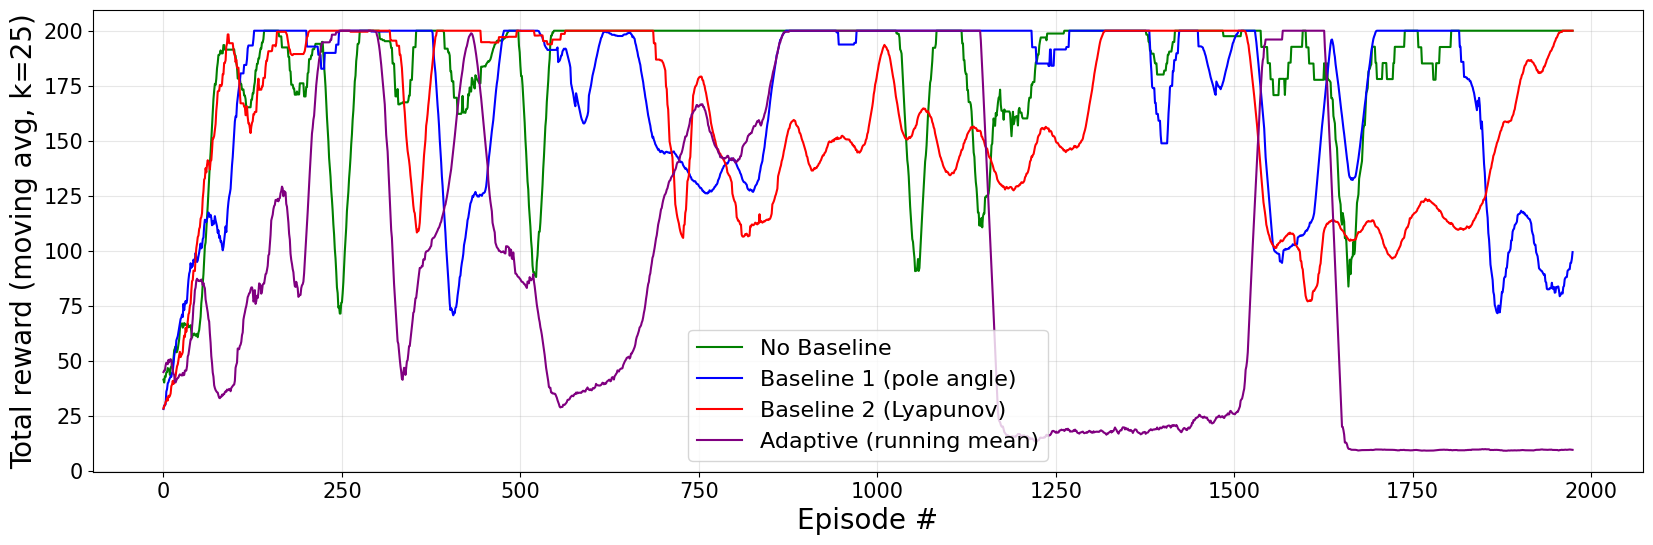

In [26]:
### Plot the learning progress

fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Smooth with a moving average so the curves are readable
def smooth(x, k=25):
    x = np.asarray(x, dtype=float)
    if len(x) < k: return x
    return np.convolve(x, np.ones(k)/k, mode='valid')

ax.plot(smooth(scores_rwd2go),    color='green', label='No Baseline')
ax.plot(smooth(scores_baseline_1), color='blue',  label='Baseline 1 (pole angle)')
ax.plot(smooth(scores_baseline_2), color='red',   label='Baseline 2 (Lyapunov)')
ax.plot(smooth(scores_adaptive),   color='purple', label='Adaptive (running mean)')

ax.set_ylabel('Total reward (moving avg, k=25)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(fontsize=16); ax.grid(alpha=0.3)
plt.show()


### Discussion

- **Unbiasedness.** All three baselines we considered (B1, B2, and the running-mean) only depend on $s_t$ or on past episodes — never on the current action $a_t$. So
$$\mathbb{E}_{a\sim\pi(\cdot|s)}[\nabla\!\log\pi(a|s)\,b(s)] = b(s)\,\nabla\!\!\sum_a \pi(a|s) = 0,$$
and the centred estimator $\nabla\!\log\pi(a_t|s_t)(\hat G_t - b(s_t))$ has the same expectation as the uncentred one.
- **Variance reduction.** B1 and B2 reduce variance because they approximate the qualitative shape of $V^\pi(s)$ (high in safe states, low near termination). B2 dominates because adding $\omega$ disambiguates *recovering* states from *falling* ones, two cases that have very different expected remaining lifetimes.
- **Magnitude tuning.** Hand-crafted constant scales are brittle: too small ⇒ no variance reduction, too large ⇒ wrong sign of the pseudo-advantage early in training. The running-mean baseline sidesteps this entirely by tracking the actual expected return; it is generally as good as or better than the best hand-tuned constant on CartPole.
- **Gradient flow.** Note that `baseline_values[i]` is a *plain Python float*; it is **not** a torch tensor and carries no `requires_grad`. So in `policy_loss = -log_prob * (G - b)`, gradients flow *only* through `log_prob`, never through `b(state)`. This is exactly what we want: $b$ is a control variate, not a function to be optimised.

We use `lr = 1e-2` everywhere (same as the no-baseline run) so that the comparison isolates the baseline effect from the optimiser-hyperparameter effect.
